---
# 1. Исходные данные

### 1.1 Загрузка библиотек и данных


*Загрузить данные в соответствии с вариантом задания*

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_score, recall_score, accuracy_score
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# добавими вывод сразу нескольких строк под одной ячейкой
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
# Load data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

In [3]:
X.shape
y.shape

(569, 30)

(569,)

### 1.2 Описание исходных данных


*Привести описание исходных данных, описание и типы признаков (вещественные, целочисленные, категориальные и т.д.), объём выборки, особенности данных. Сформулировать решаемую задачу, определить тип задачи (регрессия / классификация), указать входные и выходные переменные.*

Рассмотрим данные которые будем использовать для обучения.

In [4]:
print("\nИнформация о данных:")
print(X.info())


Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness erro

Всего имеется 569 элементов в выборке. Все данные вещественного типа. В данных отсутствуют пропущенные значения.

Анализируемый датасет `load_breast_cancer` содержит 30 признаков, которые описывают различные характеристики клеток опухоли.

Эти признаки можно разделить на три группы: **средние значения (mean)**, **стандартные ошибки (standard error, se)** и **"наихудшие" (worst)** значения.

Описание каждого признака из данных в разрезе групп:

**Средние значения (mean)**
`mean radius`: Средний радиус клетки.

`mean texture`: Средняя текстура клетки (изменение градации серого в изображении).

`mean perimeter`: Средний периметр клетки.

`mean area`: Средняя площадь клетки.

`mean smoothness`: Средняя гладкость клетки (локальное изменение длины радиуса).

`mean compactness`: Средняя компактность клетки (периметр² / площадь - 1.0).

`mean concavity`: Средняя вогнутость клетки (степень вогнутости контура).

`mean concave points`: Среднее количество вогнутых участков клетки.

`mean symmetry`: Средняя симметрия клетки.

`mean fractal dimension`: Средняя фрактальная размерность клетки.

**Стандартные ошибки (standard error, se)**
`radius error`: Стандартная ошибка радиуса клетки.

`texture error`: Стандартная ошибка текстуры клетки.

`perimeter error`: Стандартная ошибка периметра клетки.

`area error`: Стандартная ошибка площади клетки.

`smoothness error`: Стандартная ошибка гладкости клетки.

`compactness error`: Стандартная ошибка компактности клетки.

`concavity error`: Стандартная ошибка вогнутости клетки.

`concave points error`: Стандартная ошибка количества вогнутых участков клетки.

`symmetry error`: Стандартная ошибка симметрии клетки.

`fractal dimension error`: Стандартная ошибка фрактальной размерности клетки.

**"Наихудшие" значения (worst)**
`worst radius`: Максимальный радиус клетки.

`worst texture`: Максимальная текстура клетки.

`worst perimeter`: Максимальный периметр клетки.

`worst area`: Максимальная площадь клетки.

`worst smoothness`: Максимальная гладкость клетки.

`worst compactness`: Максимальная компактность клетки.

`worst concavity`: Максимальная вогнутость клетки.

`worst concave points`: Максимальное количество вогнутых участков клетки.

`worst symmetry`: Максимальная симметрия клетки.

`worst fractal dimension`: Максимальная фрактальная размерность клетки.

In [5]:
print("Описание переменных:")
print(X.describe())

Описание переменных:
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             

In [6]:
print("\nПервые 5 строк данных:")
print(X.head())


Первые 5 строк данных:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst p

Изучим целевую переменную `target`, которую будем предсказывать.

In [7]:
print("\nРаспределение целевой переменной:")
print(y.value_counts())


Распределение целевой переменной:
target
1    357
0    212
Name: count, dtype: int64


Целевая переменная `target` в датасете `load_breast_cancer` является бинарной и описывает тип опухоли:

`0` — злокачественная опухоль (malignant), 212 наблюдений.

`1` — доброкачественная опухоль (benign), 357 наблюдений.

Проверить соответствие можно через `data.target_names`: `['malignant', 'benign']`.
Классы несбалансированы (≈37% / 63%), поэтому при разбиении выборки используем стратификацию, а для оценки качества смотрим не только accuracy, но и recall по злокачественному классу: пропустить злокачественную опухоль (ложноотрицательный результат) намного опаснее, чем ошибиться в обратную сторону.

### 1.3 Выборочные характеристики

*Рассчитать основные выборочные характеристики (среднее, дисперсию, среднеквадратическое отклонение, медиану и т.д.), привести объемы выборок в каждом классе (для задач классификации)*

In [8]:
mean_values = X.mean()
variance_values = X.var()
std_dev_values = X.std()
median_values = X.median()

print("\nСредние значения:\n", mean_values)
print("\nДисперсия:\n", variance_values)
print("\nСреднеквадратическое отклонение:\n", std_dev_values)
print("\nМедиана:\n", median_values)


Средние значения:
 mean radius                 14.127292
mean texture                19.289649
mean perimeter              91.969033
mean area                  654.889104
mean smoothness              0.096360
mean compactness             0.104341
mean concavity               0.088799
mean concave points          0.048919
mean symmetry                0.181162
mean fractal dimension       0.062798
radius error                 0.405172
texture error                1.216853
perimeter error              2.866059
area error                  40.337079
smoothness error             0.007041
compactness error            0.025478
concavity error              0.031894
concave points error         0.011796
symmetry error               0.020542
fractal dimension error      0.003795
worst radius                16.269190
worst texture               25.677223
worst perimeter            107.261213
worst area                 880.583128
worst smoothness             0.132369
worst compactness            0

Всего для расчёта описательных статистик у нас имелось 569 наблюдений в данных с заполненнными значениями.

### 1.4 Исследование распределений признаков и откликов


*Построить гистограммы распределения и диаграммы Box-and-Whisker (для отдельных признаков при большом их числе), сделать выводы о характере распределений признаков (для задач классификации - в классах), наличии выбросов и т.п.*

array([[<Axes: title={'center': 'mean radius'}>,
        <Axes: title={'center': 'mean texture'}>,
        <Axes: title={'center': 'mean perimeter'}>,
        <Axes: title={'center': 'mean area'}>,
        <Axes: title={'center': 'mean smoothness'}>],
       [<Axes: title={'center': 'mean compactness'}>,
        <Axes: title={'center': 'mean concavity'}>,
        <Axes: title={'center': 'mean concave points'}>,
        <Axes: title={'center': 'mean symmetry'}>,
        <Axes: title={'center': 'mean fractal dimension'}>],
       [<Axes: title={'center': 'radius error'}>,
        <Axes: title={'center': 'texture error'}>,
        <Axes: title={'center': 'perimeter error'}>,
        <Axes: title={'center': 'area error'}>,
        <Axes: title={'center': 'smoothness error'}>],
       [<Axes: title={'center': 'compactness error'}>,
        <Axes: title={'center': 'concavity error'}>,
        <Axes: title={'center': 'concave points error'}>,
        <Axes: title={'center': 'symmetry error'}>

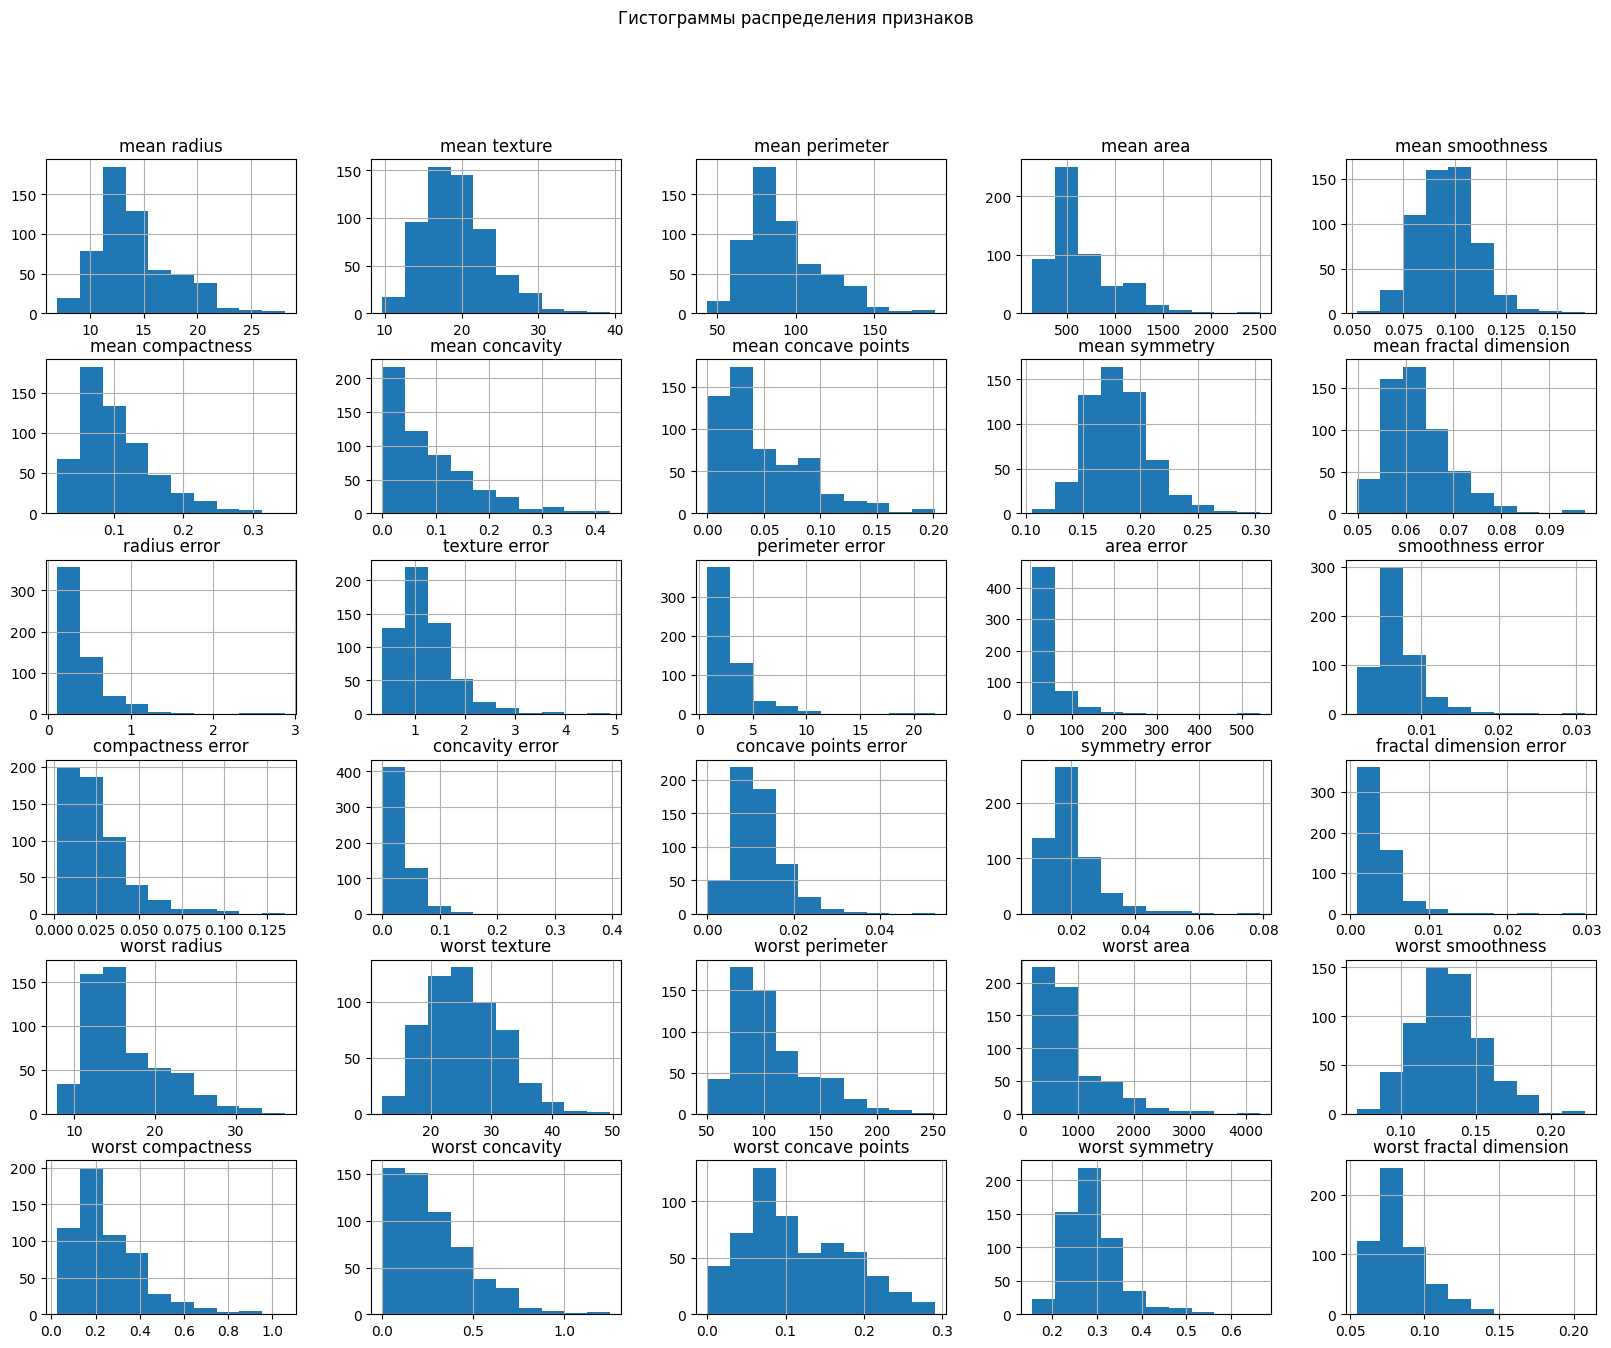

In [9]:
# Histograms
X.hist(figsize=(20, 15))
_ = plt.suptitle('Гистограммы распределения признаков')
plt.show()

mean radius                   Axes(0.125,0.747241;0.110714x0.132759)
mean texture               Axes(0.257857,0.747241;0.110714x0.132759)
mean perimeter             Axes(0.390714,0.747241;0.110714x0.132759)
mean area                  Axes(0.523571,0.747241;0.110714x0.132759)
mean smoothness            Axes(0.656429,0.747241;0.110714x0.132759)
mean compactness           Axes(0.789286,0.747241;0.110714x0.132759)
mean concavity                Axes(0.125,0.587931;0.110714x0.132759)
mean concave points        Axes(0.257857,0.587931;0.110714x0.132759)
mean symmetry              Axes(0.390714,0.587931;0.110714x0.132759)
mean fractal dimension     Axes(0.523571,0.587931;0.110714x0.132759)
radius error               Axes(0.656429,0.587931;0.110714x0.132759)
texture error              Axes(0.789286,0.587931;0.110714x0.132759)
perimeter error               Axes(0.125,0.428621;0.110714x0.132759)
area error                 Axes(0.257857,0.428621;0.110714x0.132759)
smoothness error           Axes(0.

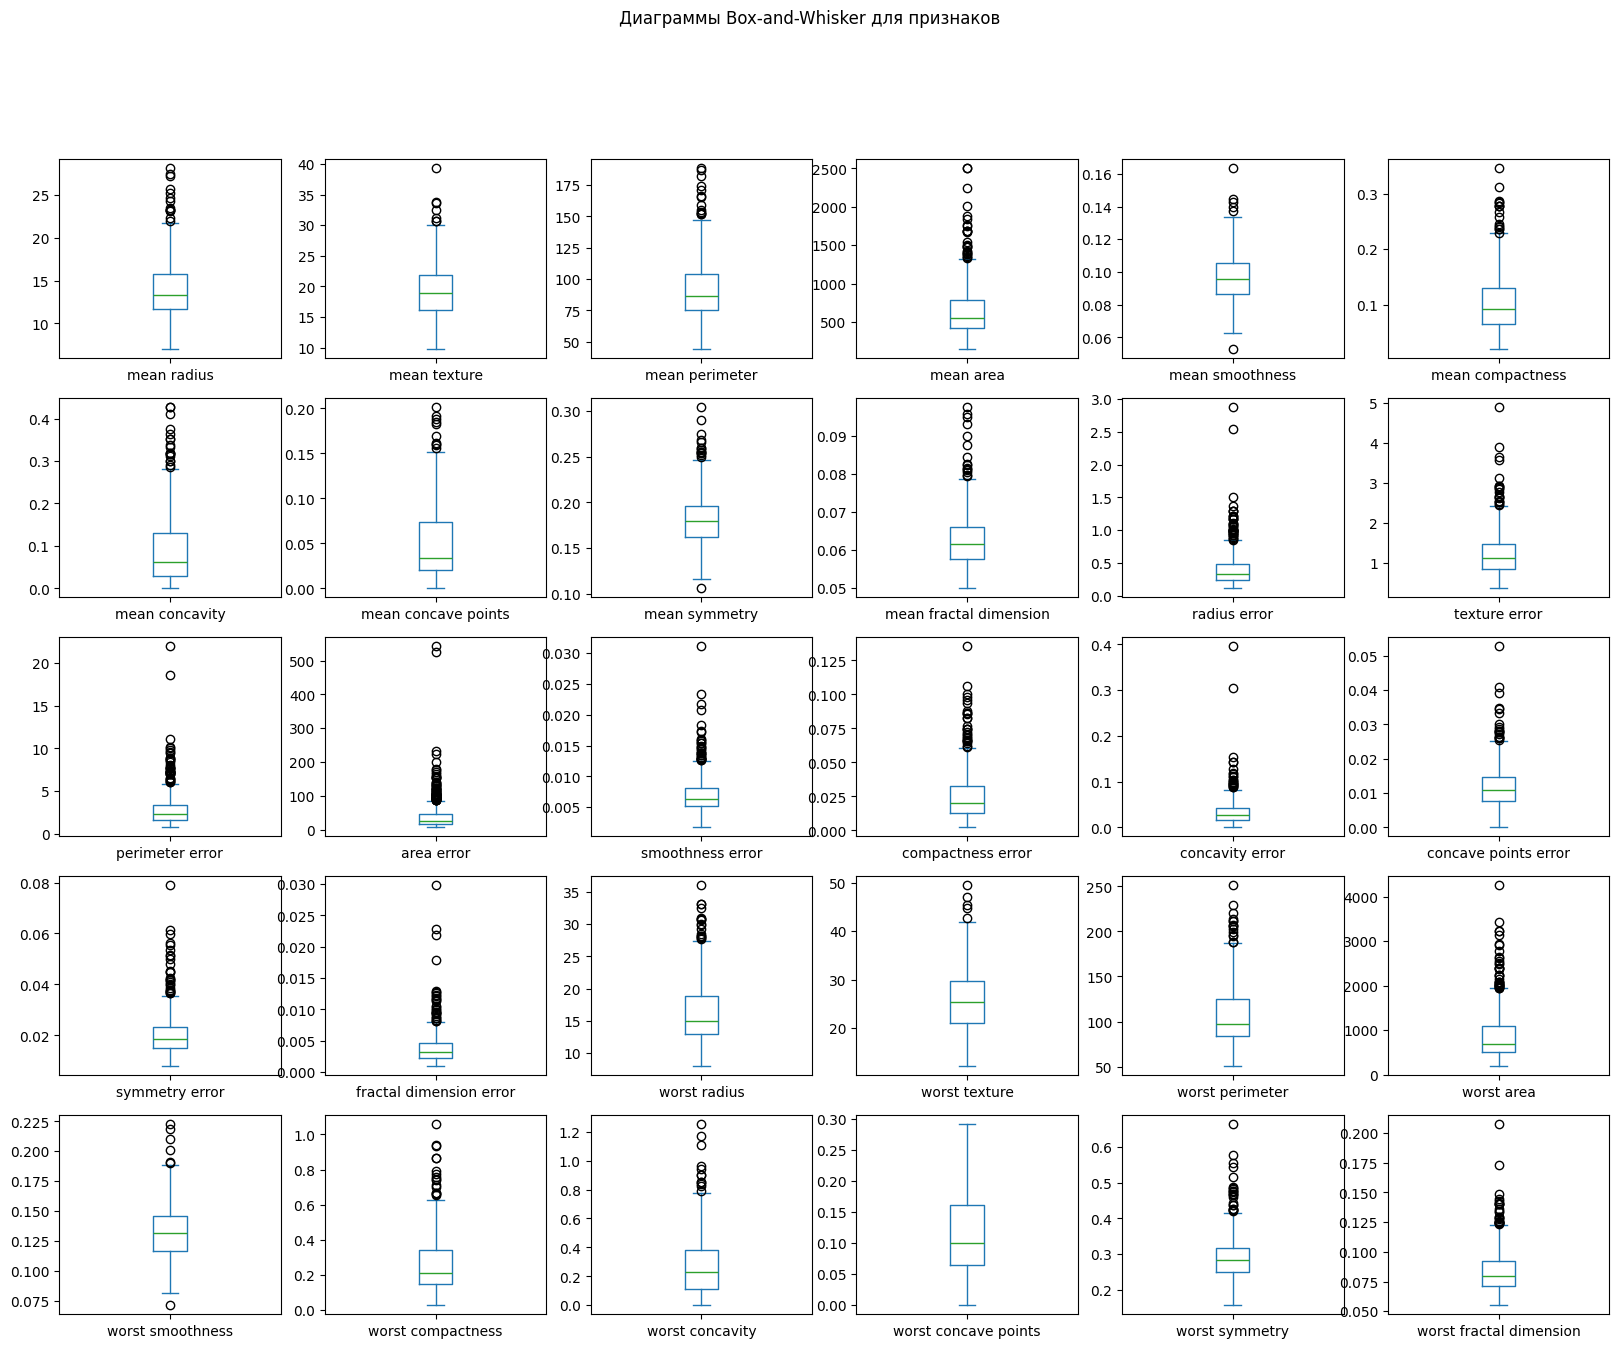

In [10]:
# Box-and-Whisker plots
X.plot(kind='box', subplots=True, layout=(5,6), figsize=(20,15), sharex=False, sharey=False)
_ = plt.suptitle('Диаграммы Box-and-Whisker для признаков')
plt.show()

### 1.5 Корреляционный анализ данных


*Визуализировать диаграммы рассеяния и корреляционную матрицу признаков, сделать выводы*

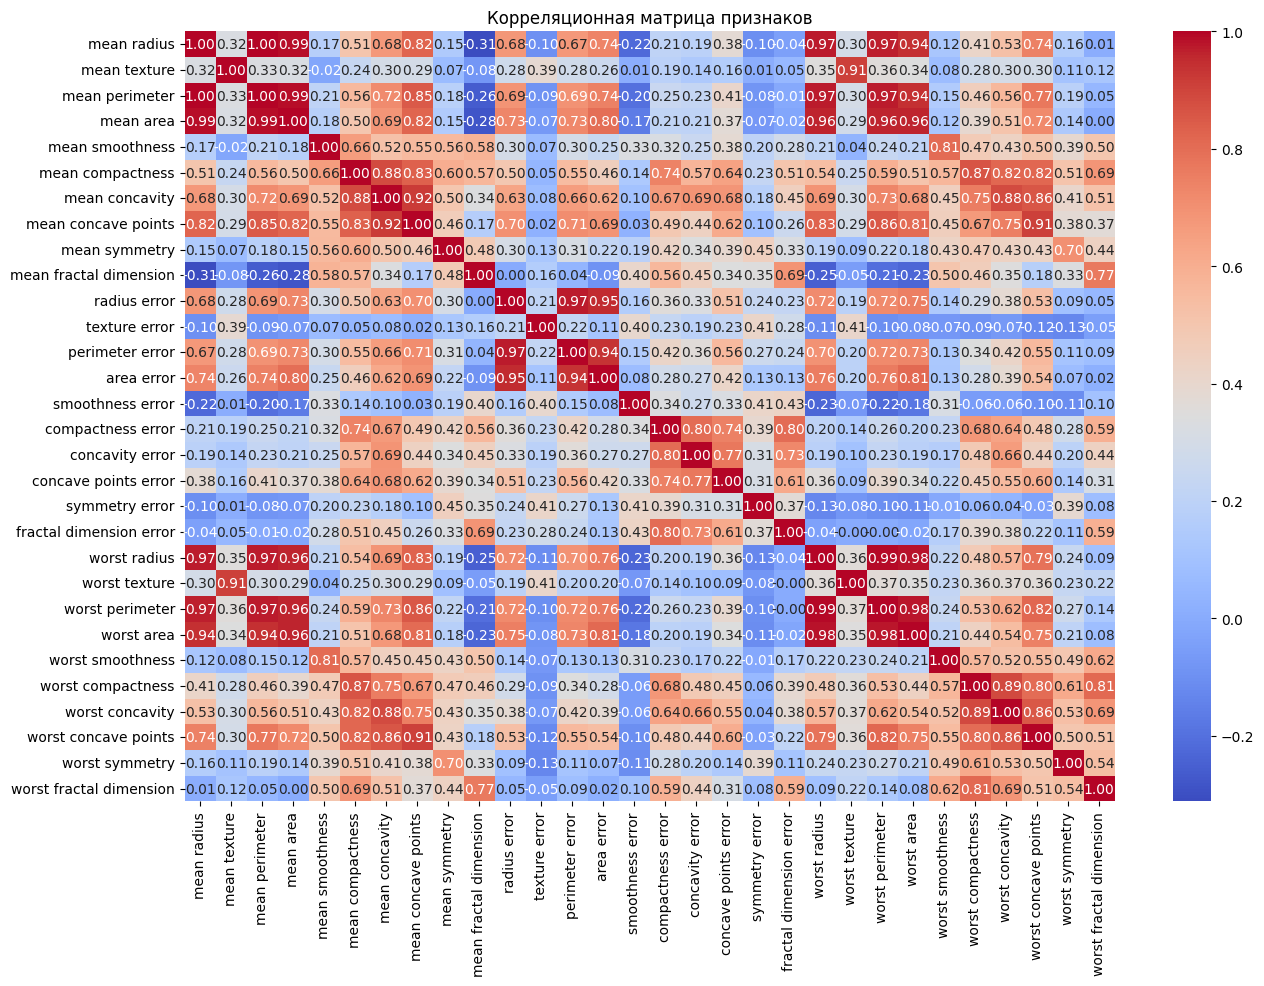

In [11]:
# Correlation matrix
corr_matrix = X.corr()
_ = plt.figure(figsize=(15, 10))
_ = sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
_ = plt.title('Корреляционная матрица признаков')
plt.show()

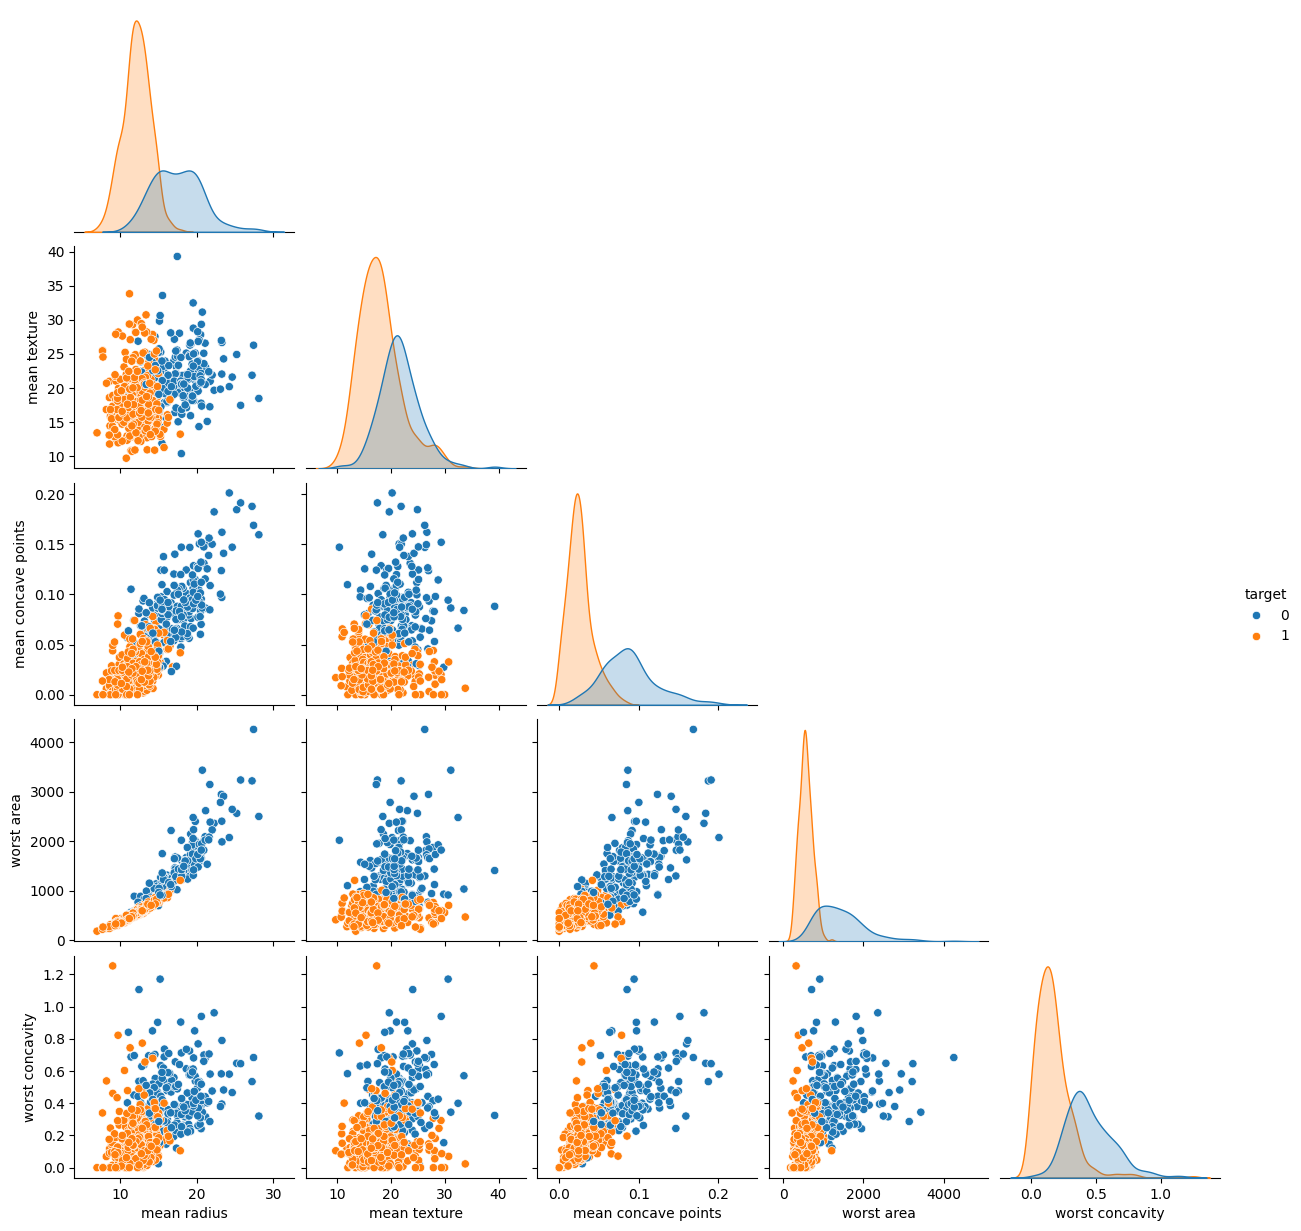

In [12]:
# Диаграммы рассеяния для нескольких ключевых признаков в разрезе классов
key_features = ['mean radius', 'mean texture', 'mean concave points', 'worst area', 'worst concavity']
_ = sns.pairplot(pd.concat([X[key_features], y], axis=1), hue='target', corner=True)
plt.show()

### 1.6 Выводы


*Сделать выводы по результатам предварительного визуального анализа исходных данных*

In [13]:
print("\nВыводы:")
print("Данные имеют разнообразные распределения, наблюдаются корреляции между некоторыми признаками.")
print("Признаки, такие как mean radius и mean area, имеют высокую корреляцию.")
print("Некоторые признаки имеют выбросы, что видно на диаграммах Box-and-Whisker.")


Выводы:
Данные имеют разнообразные распределения, наблюдаются корреляции между некоторыми признаками.
Признаки, такие как mean radius и mean area, имеют высокую корреляцию.
Некоторые признаки имеют выбросы, что видно на диаграммах Box-and-Whisker.


Можно еще посмотреть в разрезе классов (0 и 1) как у нас меняеются размеры клетко и другие характеристики и сравнить их между собой.

---
# 2. Предобработка данных

### 2.1 Очистка данных


*а) Обнаружение и устранение дубликатов*\
*б) Обнаружение и устранение выбросов*\
*в) Устранение/восстановление пропущенных значений*

In [14]:
# Detect duplicates
duplicates = X.duplicated().sum()
print(f"\nКоличество дубликатов: {duplicates}")


Количество дубликатов: 0


In [15]:
# Handle outliers (example: remove if beyond 3 standard deviations)
X_cleaned = X[(np.abs(X - X.mean()) <= (3*X.std())).all(axis=1)]
X_cleaned.shape

(495, 30)

In [16]:
X.shape

(569, 30)

Осталось 495 наблюдений вместо 569 после удаления выбросов из данных.
И с учётом, что у нас стало меньше наблюдений для обучения, то надо также удалить метки классов для тех объектов, которые удалили из выборки.

In [17]:
y_cleaned = y[X_cleaned.index]
y_cleaned.shape

(495,)

В данных нет пропущенных значений (как в исходных, так и в отфильтрованных, поэтому заполнять пропущенные значения не нужно).

Но если была бы необходимость заполнить пропущенные значения, то реализовали бы это следующим кодом:

`X_filled = X_cleaned.fillna(X_cleaned.mean())`

In [18]:
X_cleaned.info()

<class 'pandas.DataFrame'>
Index: 495 entries, 1 to 566
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              495 non-null    float64
 1   mean texture             495 non-null    float64
 2   mean perimeter           495 non-null    float64
 3   mean area                495 non-null    float64
 4   mean smoothness          495 non-null    float64
 5   mean compactness         495 non-null    float64
 6   mean concavity           495 non-null    float64
 7   mean concave points      495 non-null    float64
 8   mean symmetry            495 non-null    float64
 9   mean fractal dimension   495 non-null    float64
 10  radius error             495 non-null    float64
 11  texture error            495 non-null    float64
 12  perimeter error          495 non-null    float64
 13  area error               495 non-null    float64
 14  smoothness error         495 non-null    f

### 2.2 Разбиение данных на обучающую и тестовую выборки


*Разбить данные на обучающую и тестовую выборки в отношении 70/30*

In [19]:
SEED = 42

In [20]:
X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(X_cleaned, y_cleaned, test_size=0.3, stratify=y_cleaned, random_state=SEED)
print(X_train_cleaned.shape, X_test_cleaned.shape, y_train_cleaned.shape, y_test_cleaned.shape, sep='\n')

(346, 30)
(149, 30)
(346,)
(149,)


Здесь разделяем оригинальный датасет с выбросами.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape, sep='\n')

(398, 30)
(171, 30)
(398,)
(171,)


Также при работе с моделями машинного обучения для получения более надежных оценок метрик можно использовать кросс-валидацию.

In [22]:
# # Инициализация StratifiedKFold
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # Обучение модели и оценка производительности
# accuracies = []

# for train_index, test_index in skf.split(X, y):
#     X_train, X_test = X[train_index], X[test_index]
#     y_train, y_test = y[train_index], y[test_index]
    
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     accuracy = accuracy_score(y_test, y_pred)
#     accuracies.append(accuracy)

# print(f'Mean Accuracy: {np.mean(accuracies)}')

### 2.3 Преобразование данных

*Описать используемые способы преобразования входных и выходных переменных, привести обоснования выбранных способов преобразования, применить преобразования к обучающей и тестовой выборкам*

In [23]:
X_cleaned.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000,...,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000,495.000000
mean,13.868883,18.889778,89.931939,622.613333,0.095075,0.094741,0.074145,0.043306,0.177602,0.061779,...,15.846776,25.152343,103.961111,820.704848,0.130829,0.231213,0.240894,0.106625,0.283788,0.081467
std,3.042868,3.966250,20.795084,286.903247,0.012822,0.041071,0.061694,0.032550,0.023258,0.005546,...,4.130793,5.666008,28.312550,452.870860,0.021069,0.125632,0.171007,0.058203,0.049675,0.014411
min,6.981000,9.710000,43.790000,143.500000,0.062510,0.019380,0.000000,0.000000,0.116700,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.081250,0.034320,0.000000,0.000000,0.156500,0.055040
25%,11.745000,16.000000,75.475000,424.800000,0.085345,0.062310,0.027420,0.019485,0.160800,0.057490,...,13.055000,20.845000,84.440000,517.150000,0.115950,0.140000,0.106450,0.063060,0.248750,0.070830
50%,13.210000,18.580000,85.630000,538.900000,0.094620,0.085490,0.053080,0.030700,0.177100,0.061150,...,14.800000,25.110000,96.530000,670.000000,0.130100,0.203100,0.195600,0.092220,0.278500,0.078750
75%,15.290000,21.460000,100.250000,718.050000,0.103700,0.120150,0.107250,0.062770,0.193000,0.065105,...,17.730000,28.900000,117.700000,970.050000,0.143600,0.305050,0.349200,0.148950,0.311300,0.089850
max,23.270000,30.720000,152.100000,1686.000000,0.137100,0.228400,0.317400,0.156200,0.254000,0.079760,...,28.190000,41.610000,195.900000,2403.000000,0.190900,0.664300,0.848900,0.270100,0.475300,0.134100


После просмотра описательных статистик по каждому признаку видим, что некоторые признаки в разных масштабах, что может сказаться на качестве и производительности итоговой модели.

Поэтому произведем масштабирование признаков с использованием алгоритма `StandardScaler`.

In [24]:
# 2.3 Преобразование данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Делаем преобразование на данных без выбросов.

In [25]:
clean_scaler = StandardScaler()
X_train_scaled_clean = clean_scaler.fit_transform(X_train_cleaned)
X_test_scaled_clean = clean_scaler.transform(X_test_cleaned)

In [26]:
X_train_scaled

array([[-0.70982078, -0.258417  , -0.63739619, ...,  0.40093281,
        -0.41407439,  0.44522333],
       [-0.83033136,  2.2311266 , -0.87497994, ..., -1.69278836,
        -2.09572345, -1.32341746],
       [-1.01109725, -0.22726989, -1.03517213, ..., -1.36423974,
        -0.35412529, -0.88664465],
       ...,
       [-0.12735293, -1.37526319, -0.15890003, ..., -0.50161479,
        -0.84447817,  0.15509266],
       [ 0.84820898, -0.05818561,  0.90294536, ...,  2.06733377,
         0.27610881,  0.33537313],
       [-1.20219261, -0.28511452, -1.1275427 , ..., -0.22747926,
        -0.48478358,  1.68038109]], shape=(398, 30))

In [27]:
X_train_scaled_clean

array([[-0.15712596, -0.60416419, -0.17711217, ..., -0.26949349,
        -1.61857803, -0.35571414],
       [-0.35883982,  0.65265941, -0.37823973, ..., -0.98358658,
        -1.35860111, -0.8651676 ],
       [ 1.74234618,  1.44881459,  1.59261325, ...,  1.52754173,
         2.16795608,  0.76144933],
       ...,
       [ 0.81782434,  0.47740512,  0.84824406, ...,  0.89411314,
         0.47512925,  0.02923617],
       [-0.74545804, -0.15601394, -0.65626902, ...,  0.61051374,
        -0.40402935,  0.74933551],
       [ 0.09165446, -1.48293925,  0.01662101, ..., -0.79389764,
        -1.51538108, -0.72249371]], shape=(346, 30))

---
# 3. Построение и исследование модели машинного обучения

### 3.1 Обучение модели


*Выбрать модель и алгоритм машинного обучения для решения поставленной задачи, привести обоснование выбора, обучить модель на обучающей выборке*

В качестве базового решения (baseline) используем модель `LogisticRegression`.

In [28]:
model = LogisticRegression(random_state=SEED)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [29]:
model_cleaned_data = LogisticRegression(random_state=SEED)
model_cleaned_data.fit(X_train_scaled_clean, y_train_cleaned)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### 3.2 Оценка качества модели


**Для задач регрессии:**
* *построить диаграммы рассеяния в пространстве «выход модели – желаемый выход» на данных обучающей и тестовой выборок*
* *построить линейные регрессии выхода модели на желаемый выход*
* *рассчитать коэффициенты детерминации линейных регрессионных моделей для обучающей и тестовой выборок*
* *построить гистограммы распределения ошибок модели.*

**Для задач классификации:**
* *построить матрицы ошибок (confusion matrix) классификатора и рассчитать показатели качества классификации (чувствительность, специфичность, точность, F-мера, каппа Коэна) на обучающей и тестовой выборках.*

In [30]:
y_pred = model.predict(X_test_scaled)
print("\nМатрица ошибок на оригинальных данных:")
print(confusion_matrix(y_test, y_pred))

print("\nОтчет по классификации на оригинальных данных:")
print(classification_report(y_test, y_pred))


Матрица ошибок на оригинальных данных:
[[ 63   1]
 [  1 106]]

Отчет по классификации на оригинальных данных:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        64
           1       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



In [31]:
y_pred_cleaned = model_cleaned_data.predict(X_test_scaled_clean)
print("\nМатрица ошибок на данных где удалили выбросы:")
print(confusion_matrix(y_test_cleaned, y_pred_cleaned))

print("\nОтчет по классификации где удалили выбросы:")
print(classification_report(y_test_cleaned, y_pred_cleaned))


Матрица ошибок на данных где удалили выбросы:
[[ 49   0]
 [  0 100]]

Отчет по классификации где удалили выбросы:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
           1       1.00      1.00      1.00       100

    accuracy                           1.00       149
   macro avg       1.00      1.00      1.00       149
weighted avg       1.00      1.00      1.00       149



На данных без выбросов модель ошибается 0 раз — **к такому результату стоит относиться с подозрением**, а не радоваться.
Удаляя «выбросы», мы убрали самые крупные и нетипичные клетки — а это как раз сложные, в основном злокачественные случаи.
Модель получила более лёгкую задачу, чем в реальности: в клинике такие пациенты никуда не исчезнут.
Кроме того, границы выбросов считались по всей выборке до разбиения, то есть с участием теста.

Поэтому основной считаем модель на **исходных данных**, а вариант без выбросов — как эксперимент, который показывает риск такой очистки.

### 3.3 Исследование модели и алгоритма обучения


*Провести экспериментальные исследования модели, построить графики зависимости ошибки модели от ее архитектурных параметров и гиперпараметров алгоритма обучения, построить ROC-кривые, оценить степень важности признаков и пр.*

Построение ROC-кривой.

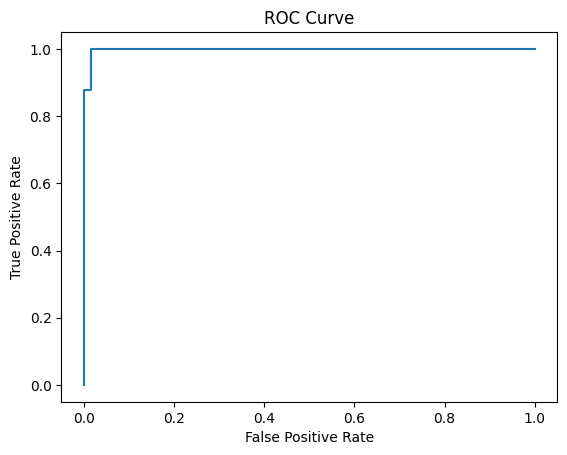


AUC Score: 0.9981016355140186


In [32]:
y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
_ = plt.plot(fpr, tpr)
_ = plt.xlabel('False Positive Rate')
_ = plt.ylabel('True Positive Rate')
_ = plt.title('ROC Curve')
plt.show()

print("\nAUC Score:", roc_auc_score(y_test, y_pred_proba))

In [33]:
model.coef_

array([[-0.49499939, -0.45979525, -0.45978281, -0.54984048, -0.1672432 ,
         0.65265465, -0.53260146, -0.63065394, -0.11381252,  0.03618538,
        -0.88637017,  0.36776094, -0.20498755, -0.93749327, -0.18501794,
         0.5687022 ,  0.16374479, -0.26820006,  0.32489383,  0.34955732,
        -0.94105951, -1.22632911, -0.73104215, -0.95495624, -0.7489706 ,
         0.03592003, -0.78598887, -0.99680696, -0.86944423, -0.16426367]])

Оценка степени важности признаков.

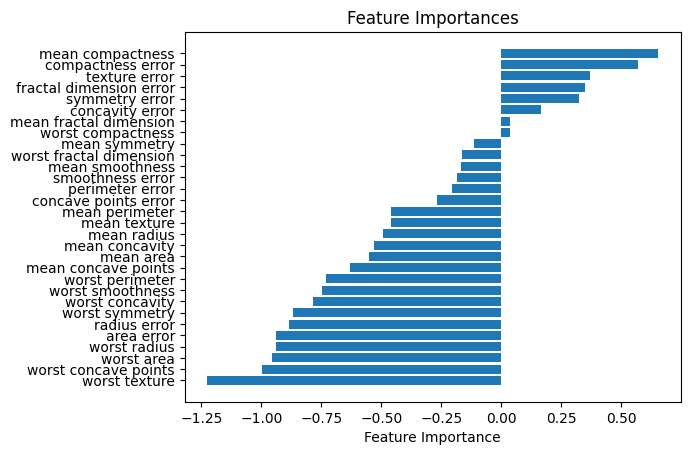

In [34]:
coef = model.coef_[0]
feature_names = data.feature_names

# Сортировка признаков по важности
sorted_idx = coef.argsort()

# Построение графика важности признаков
_ = plt.barh(range(len(sorted_idx)), coef[sorted_idx], align='center')
_ = plt.yticks(range(len(sorted_idx)), feature_names[sorted_idx])
_ = plt.xlabel('Feature Importance')
_ = plt.title('Feature Importances')
plt.show()

Графики зависимости качества модели от гиперпараметра регуляризации `C`.

Гиперпараметр подбираем **кросс-валидацией на обучающей выборке**, а не по тестовой: если выбирать `C` по тесту, тест перестаёт быть независимой оценкой, и итоговое качество окажется завышенным.

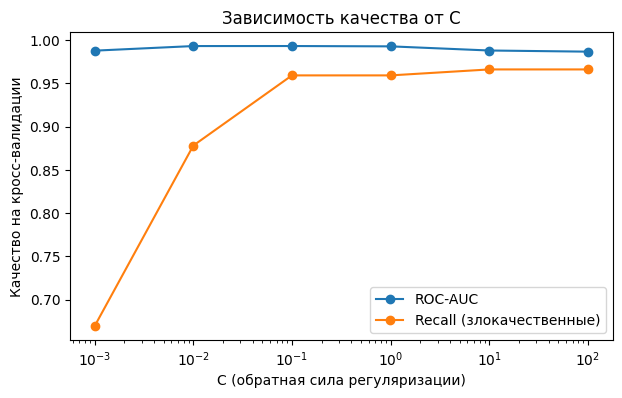

,C,cv_roc_auc,cv_recall_malignant
0,0.001,0.9879,0.6694
1,0.010,0.9932,0.8782
2,0.100,0.9933,0.9593
3,1.000,0.9929,0.9593
4,10.000,0.9881,0.9662
5,100.000,0.9868,0.9662


In [35]:
C_range = [0.001, 0.01, 0.1, 1, 10, 100]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_auc, cv_recall0 = [], []
for C in C_range:
    lr_model = LogisticRegression(C=C, random_state=SEED, max_iter=1000)
    cv_auc.append(cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc').mean())
    # recall по злокачественному классу (метка 0): pos_label задаём через make_scorer
    from sklearn.metrics import make_scorer
    rec0 = make_scorer(recall_score, pos_label=0)
    cv_recall0.append(cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring=rec0).mean())

_ = plt.figure(figsize=(7, 4))
_ = plt.semilogx(C_range, cv_auc, marker='o', label='ROC-AUC')
_ = plt.semilogx(C_range, cv_recall0, marker='o', label='Recall (злокачественные)')
_ = plt.xlabel('C (обратная сила регуляризации)'); _ = plt.ylabel('Качество на кросс-валидации')
_ = plt.title('Зависимость качества от C'); _ = plt.legend()
plt.show()

pd.DataFrame({'C': C_range, 'cv_roc_auc': np.round(cv_auc, 4), 'cv_recall_malignant': np.round(cv_recall0, 4)})

### 3.4 Улучшение решения


*Предложить возможное улучшение точности решения задачи (выбрать другой тип модели, алгоритм или критерий обучения, сформулировать рекомендации по возможным способам повышения точности модели), обучить модель и сравнить показатели точности с рассчитанными в п.3.2*

Попробоуем в качестве улучшения решения модели `SVM` и модель из класса решающих деревьев `RandomForestClassifier`.

In [36]:
svm_model = SVC(probability=True)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_svm_proba = svm_model.predict_proba(X_test_scaled)[:,1]

print("\nМатрица ошибок для SVM:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nОтчет по классификации для SVM:")
print(classification_report(y_test, y_pred_svm))

print("\nAUC Score для SVM:", roc_auc_score(y_test, y_pred_svm_proba))

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False



Матрица ошибок для SVM:
[[ 62   2]
 [  2 105]]

Отчет по классификации для SVM:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        64
           1       0.98      0.98      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171


AUC Score для SVM: 0.9978095794392523


In [37]:
rf_model = RandomForestClassifier(random_state=SEED)
rf_model.fit(X_train_scaled, y_train)


y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\nМатрица ошибок для RandomForestClassifier:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nОтчет по классификации для RandomForestClassifier:")
print(classification_report(y_test, y_pred_rf))

print("\nAUC Score для RandomForestClassifier:", roc_auc_score(y_test, y_pred_rf_proba))

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric


Матрица ошибок для RandomForestClassifier:
[[ 58   6]
 [  5 102]]

Отчет по классификации для RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91        64
           1       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171


AUC Score для RandomForestClassifier: 0.991311331775701


Можно еще добавить подбор параметров по сетке.

In [38]:
# Определение сетки параметров для GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 1, 10]
}

# Создание и обучение модели SVM с использованием GridSearchCV
svm_model = SVC(probability=True)
grid_search = GridSearchCV(svm_model, param_grid, cv=3, scoring='roc_auc')
grid_search.fit(X_train_scaled, y_train)

# Вывод лучших параметров
print("Лучшие параметры:", grid_search.best_params_)

# Предсказание классов на тестовой выборке с использованием лучшей модели
best_svm_model = grid_search.best_estimator_
y_pred_svm = best_svm_model.predict(X_test_scaled)

# Предсказание вероятностей для положительного класса на тестовой выборке
y_pred_svm_proba = best_svm_model.predict_proba(X_test_scaled)[:, 1]

# Вывод матрицы ошибок для SVM
print("\nМатрица ошибок для SVM:")
print(confusion_matrix(y_test, y_pred_svm))

# Вывод отчета по классификации для SVM
print("\nОтчет по классификации для SVM:")
print(classification_report(y_test, y_pred_svm))

# Вывод AUC Score для SVM
print("\nAUC Score для SVM:", roc_auc_score(y_test, y_pred_svm_proba))

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(probability=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['linear', 'rbf', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sco

Лучшие параметры: {'C': 100, 'gamma': 'auto', 'kernel': 'poly'}

Матрица ошибок для SVM:
[[ 61   3]
 [  1 106]]

Отчет по классификации для SVM:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97        64
           1       0.97      0.99      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171


AUC Score для SVM: 0.9976635514018691


### 3.5 Выводы


*Сделать выводы по результатам проведенных исследований*

In [39]:
print("""Выводы:
1. Логистическая регрессия на масштабированных признаках — сильный baseline: ROC-AUC ≈ 0.998 на тесте,
   ошибки: 1 злокачественная опухоль пропущена, 1 доброкачественная ошибочно отнесена к злокачественным.
2. Регуляризацию C подбирали кросс-валидацией на обучении: при слишком сильной регуляризации (C=0.001)
   резко падает recall по злокачественным (≈0.67), оптимальная зона — C от 0.1 до 1.
3. SVM и RandomForest не превзошли логистическую регрессию; для медицинской задачи выбираем интерпретируемую модель.
4. Удаление выбросов дало «идеальный» результат, но это артефакт: из данных ушли сложные случаи.
5. Ключевая метрика для задачи — recall по злокачественному классу, т.к. пропуск опухоли опаснее ложной тревоги.
   Можно дополнительно сдвинуть порог вероятности, чтобы снизить число пропусков ценой ложных тревог.""")

Выводы:
1. Логистическая регрессия на масштабированных признаках — сильный baseline: ROC-AUC ≈ 0.998 на тесте,
   ошибки: 1 злокачественная опухоль пропущена, 1 доброкачественная ошибочно отнесена к злокачественным.
2. Регуляризацию C подбирали кросс-валидацией на обучении: при слишком сильной регуляризации (C=0.001)
   резко падает recall по злокачественным (≈0.67), оптимальная зона — C от 0.1 до 1.
3. SVM и RandomForest не превзошли логистическую регрессию; для медицинской задачи выбираем интерпретируемую модель.
4. Удаление выбросов дало «идеальный» результат, но это артефакт: из данных ушли сложные случаи.
5. Ключевая метрика для задачи — recall по злокачественному классу, т.к. пропуск опухоли опаснее ложной тревоги.
   Можно дополнительно сдвинуть порог вероятности, чтобы снизить число пропусков ценой ложных тревог.
